In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import scipy.stats as stat
import altair as alt
import timeit

In [2]:
df_subject_info = pd.read_csv ('subject-info.csv') 
df_test_measure = pd.read_csv ('test_measure.csv')
#Merge the datasets on ID
merged_data = pd.merge (df_subject_info, df_test_measure, on='ID')

In [146]:
#49. Identify the test name that had the shortest time duration. 

#Group by ID_test and calculate the duration of each test
test_duration = df2.groupby ('ID_test')['time'].max().reset_index()
#Rename the columns
test_duration.columns = ['ID_test', 'duration']
#Find the test with the shortest duration
shortest_test = test_duration.loc [test_duration['duration'].idxmin()]
print ("The test name with the shortest duration is:", shortest_test['ID_test'])

The test name with the shortest duration is: 564_1


In [147]:
#50. What is the percentage difference in mean Carbon dioxide production between male and female athletes?

#Filter out the rows with missing VCO2 values
merged_data = merged_data.dropna (subset= ['VCO2'])
#Calculate mean VCO2 by sex
mean_male_vco2 = merged_data [merged_data ['Sex'] == 0] ['VCO2'].mean()
mean_female_vco2 = merged_data [merged_data ['Sex'] == 1] ['VCO2'].mean()
#Calculate percentage diff
percentage_diff = ((mean_male_vco2 - mean_female_vco2) / mean_female_vco2) * 100
print ("Percentage difference in mean Carbon dioxide production between male and female athletes:", percentage_diff)  

Percentage difference in mean Carbon dioxide production between male and female athletes: 41.430933327674005


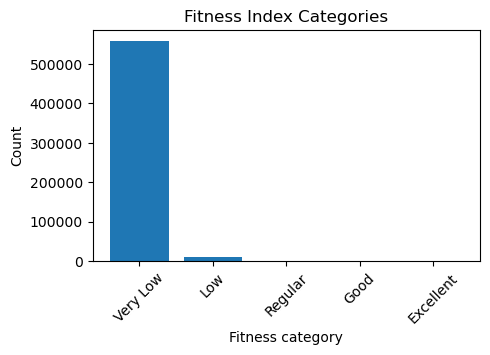

In [148]:
#51. Calculate the Fitness Index, generate a bar chart of Fitness Index categories, and export it as SVG file.

#Merge the datasets on ID_test
merged_data = pd.merge (df_subject_info, df_test_measure, on='ID_test')
#Calculate Fitness Index
merged_data['Fitness Index'] = (merged_data['Speed']*100) / (merged_data['Weight'] * (50/merged_data['Age']))
#Categorize Fitness Index
bins = [0,20,40,60,80,100]
labels = ['Very Low', 'Low', 'Regular', 'Good', 'Excellent']
merged_data['Fitness category'] = pd.cut (merged_data['Fitness Index'], bins= bins, labels= labels)
#Calculate count of each category 
category_counts = merged_data['Fitness category'].value_counts()
#Generate bar chart
plt.figure (figsize= (5,3))
plt.bar (category_counts.index, category_counts.values)
plt.xlabel ('Fitness category')
plt.ylabel ('Count')
plt.title ('Fitness Index Categories')
plt.xticks (rotation= 45)
#Export as SVG file
plt.savefig ('fitness_index_cateories', bbox_inches= 'tight')


In [149]:
#52. "arr=np.array([ [3, 5, 7, 9], [2, 0, 8, 10], [1, 4, 8, 12], [5, 9, 14, 15] ])
#Transpose this numpy matrix. and calculate sum of each row after transposing. Find the row with highest sum(after transposing)

arr = np.array([ [3, 5, 7, 9], [2, 0, 8, 10], [1, 4, 8, 12], [5, 9, 14, 15] ])
#Transpose the array
transposed_arr = arr.T
#Calculate the sum of each row after transposing
row_sums = np.sum (transposed_arr, axis=1)
#Find the row with highest sum
highest_sum_index = np.argmax (row_sums)
highest_sum_row = transposed_arr[highest_sum_index]
#Calculate maximum sum value
max_sum = np.max (row_sums)
print ("Original Array:\n", arr)
print ("\nTransposed Array:\n", transposed_arr)
print ("\nSum of each row after transposing:\n", row_sums)
print ("\nRow with highest sum:\n", highest_sum_row)
print ("\nmaximum sum value:", max_sum) 

Original Array:
 [[ 3  5  7  9]
 [ 2  0  8 10]
 [ 1  4  8 12]
 [ 5  9 14 15]]

Transposed Array:
 [[ 3  2  1  5]
 [ 5  0  4  9]
 [ 7  8  8 14]
 [ 9 10 12 15]]

Sum of each row after transposing:
 [11 18 37 46]

Row with highest sum:
 [ 9 10 12 15]

maximum sum value: 46


In [169]:
#53 Display participant details with highest average cardiorespiratory fitness in terms of VO2 max.

#Calculating VO2 max
merged_data['VO2_max'] =  merged_data['VO2'] / merged_data['Weight']
#Calculating average VO2 max for each participant
avg_VO2_max = merged_data.groupby('ID')['VO2_max'].mean().reset_index()
#Finding the participant with the highest average VO2 max
highest_avg_VO2_max_participant = avg_VO2_max.loc [avg_VO2_max['VO2_max'].idxmax()]
#Getting the participant's details
participant_details = df_subject_info.loc [df_subject_info['ID'] == highest_avg_VO2_max_participant['ID']]
print (participant_details)

      Age  Weight  Height  Humidity  Temperature  Sex   ID ID_test
350  23.6    86.0   190.0      45.0         32.0    0  409   409_1


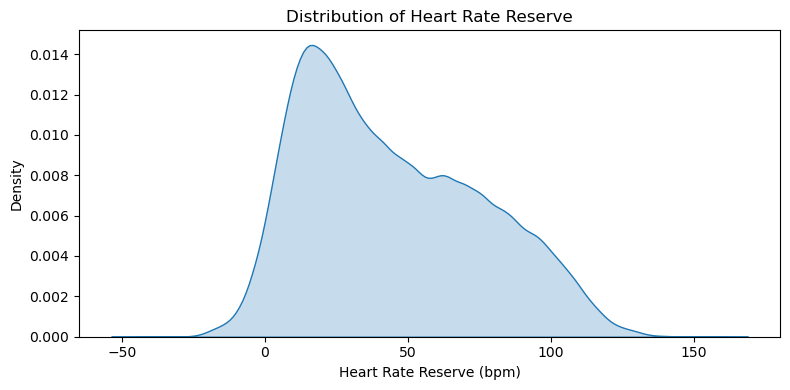

In [155]:
#54 calculate the heart rate reserve and show the distribution as density plot

#Calculate the maximum heart rate for each participant
merged_data['Max_HR'] = 220 - merged_data['Age']
#Calculate the heart rate reserve for each participant
merged_data['HRR'] = merged_data['Max_HR'] - merged_data['HR']
#Genarate the density plot
plt.figure (figsize= (8,4))
sbn.kdeplot (merged_data['HRR'], fill= True)
plt.title ('Distribution of Heart Rate Reserve')
plt.xlabel ('Heart Rate Reserve (bpm)')
plt.ylabel ('Density')
plt.tight_layout()
plt.show()

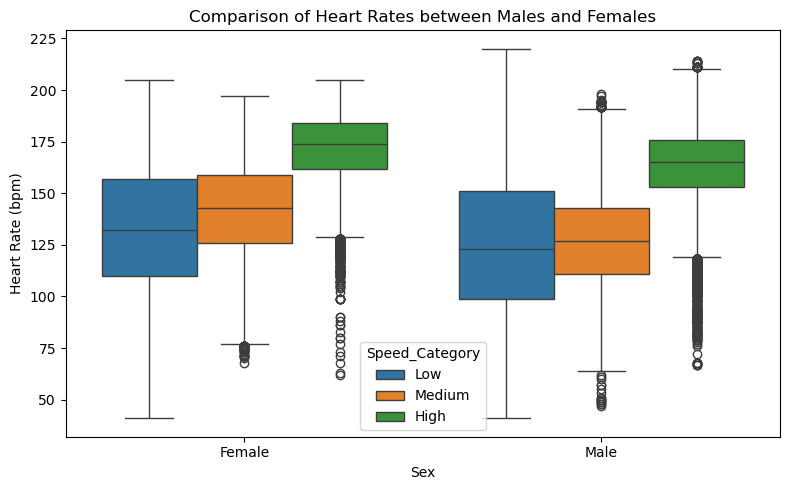

In [157]:
#55. Create a boxplot comparing heart rates between males and females, showing hue as speed category.

#Create a new column for speed category 
merged_data['Speed_Category'] = pd.cut (merged_data['Speed'], bins= [0,5,10,15], labels= ['Low', 'Medium', 'High'])
#Map sex values to male and female
merged_data['Sex'] = merged_data['Sex'].map({0: 'Male', 1: 'Female'})
#Create a boxplot
plt.figure (figsize= (8,5))
sbn.boxplot (data= merged_data, x= 'Sex', y= 'HR', hue= 'Speed_Category')
plt.title ('Comparison of Heart Rates between Males and Females')
plt.xlabel ('Sex')
plt.ylabel ('Heart Rate (bpm)')
plt.tight_layout()
plt.show()

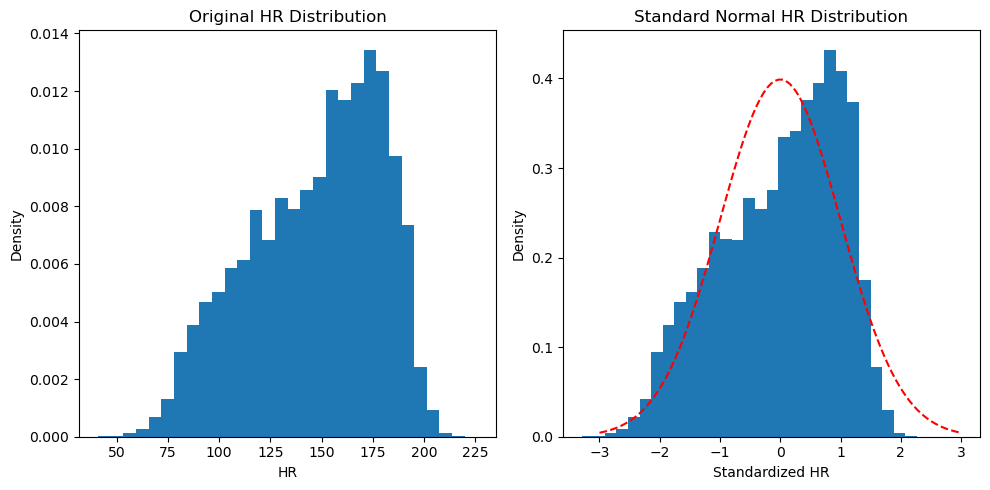

In [159]:
#56. Choose any feature that follows a Gaussian distribution, convert it into a standard normal distribution, and visualize the results?

#Select the HR feature
hr = df_test_measure['HR']
#Calculate the mean and standard deviation
mean = hr.mean()
std_dev = hr.std()
#Convert the HR feature into standard normal distribution 
std_normal_hr = (hr-mean)/std_dev
#Plot the original HR feature
plt.figure (figsize= (10,5))
plt.subplot (1,2,1)
plt.hist (hr, bins= 30, density= True)
plt.title ('Original HR Distribution')
plt.xlabel ('HR')
plt.ylabel ('Density')
#Plot the standard normal HR feature
plt.subplot (1,2,2)
plt.hist (std_normal_hr, bins= 30, density= True)
plt.title ('Standard Normal HR Distribution')
plt.xlabel ('Standardized HR')
plt.ylabel ('Density')
x = np.linspace (-3,3,100)
plt.plot (x, stat.norm.pdf(x,0,1), 'r--')
plt.tight_layout()
plt.show()

In [161]:
#57. Identify the participant who has taken maximum number of Graded Exercise test and justify.

#Count the number of test per participant
GET_Count = df_subject_info['ID'].value_counts()
#Identify the participant with the maximum number of tests
max_GET_participant = GET_Count.idxmax()
max_GET_count = GET_Count.max()
print (f"Participant {max_GET_participant} has taken the maximum number of tests: {max_GET_count}")

#Justification:
#The participant with the maximum number of tests can be identified by counting the number of roes in the subject-info.csv file for each unique ID.
#The value_counts() method in pandas provide a convenient method to perform this count. The participant with the highest count is the one who has taken
#the maximum number of GETS

Participant 506 has taken the maximum number of tests: 5


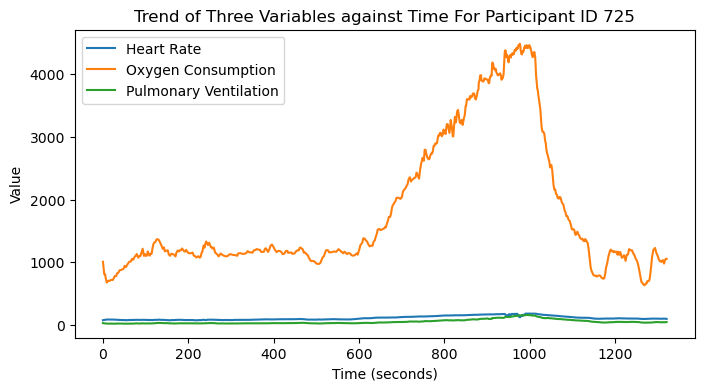

In [175]:
#58. For participant ID 725 show trend of  any three variables against time in a single canva ?

#Filter the data for participant ID 725
participant_data = df_test_measure [df_test_measure ['ID'] == 725]
#Plot the trend of three variables against time
plt.figure (figsize= (8,4))
plt.plot (participant_data['time'], participant_data['HR'], label= 'Heart Rate')
plt.plot (participant_data['time'], participant_data['VO2'], label= 'Oxygen Consumption')
plt.plot (participant_data['time'], participant_data['VE'], label= 'Pulmonary Ventilation')
plt.xlabel ('Time (seconds)')
plt.ylabel ('Value')
plt.title ('Trend of Three Variables against Time For Participant ID 725')
plt.legend()
plt.show()

In [207]:
#59. Create a scatter plot with a regression line using Altair, take a random sample data with features 'x' and 'y'.

#Take a random sample of 1000 rows
sample_data = df_test_measure [['HR', 'VO2']].sample (n=1000).rename (columns={'HR': 'x', 'VO2':'y'})
#Create scatter plot
chart = alt.Chart(sample_data).mark_point().encode(
    x=alt.X('x:Q', title= 'Heart Rate (beats/min)'),
    y=alt.Y('y:Q', title= 'Oxygen Consumption (ml/min)')
)
#Add regression line to the scatter plot
regression_line = chart.transform_regression ('x', 'y').mark_line (color= 'red')
#Combine the scatter plot and regression line into a single chart
final_chart = (chart + regression_line).properties (title= 'Relationship between Heart Rate and Oxygen Consumption')
final_chart

alt.LayerChart(...)

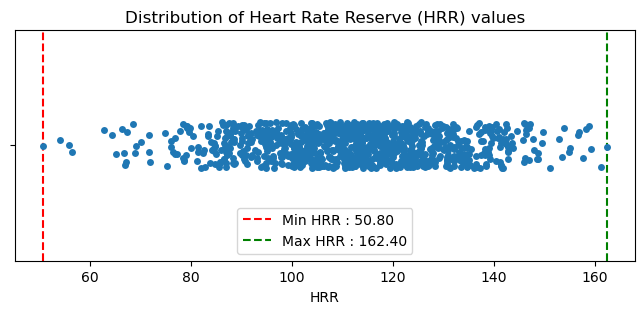

In [63]:
#60 Use a strip plot to illustrate the distribution of Heart Rate Reserve (HRR) values, highlighting the lowest and highest values to showcase the range of HRR.

merged_data = pd.merge (df_subject_info, df_test_measure, on='ID_test')
#Calculate maximum Heart Rate
merged_data['HRmax'] = 220 - merged_data['Age']
#Calculate resting Heart Rate
HR_rest = merged_data.groupby('ID_test')['HR'].min().reset_index()
HR_rest = HR_rest.rename (columns= {'HR' : 'HRrest'})
#Merging HR_rest with merged_data
merged_data = pd.merge (merged_data, HR_rest, on= 'ID_test')
#Calculate Heart Rate Reserve (HRR)
merged_data['HRR'] = merged_data['HRmax'] - merged_data['HRrest']
#Create strip plot of HRR values and drop_duplicates('ID_test') ensures that each participant is only represented once in the plot
plt.figure (figsize= (8,3))
sbn.stripplot (data= merged_data.drop_duplicates('ID_test'), x= 'HRR')
plt.title ('Distribution of Heart Rate Reserve (HRR) values')
#Highlight lowest and highest HRR values
min_HRR = merged_data['HRR'].min()
max_HRR = merged_data['HRR'].max()
plt.axvline (x= min_HRR, color= 'red', linestyle= '--', label= f'Min HRR : {min_HRR:.2f}')
plt.axvline (x= max_HRR, color= 'green', linestyle= '--', label= f'Max HRR : {max_HRR:.2f}')
#Display the labels for the minimum and maximum HRR lines
plt.legend()
plt.show()
#Calculate the minimum heart rate as HR_rest for each participant by grouping the data by ID_test and taking the minimum value of HR

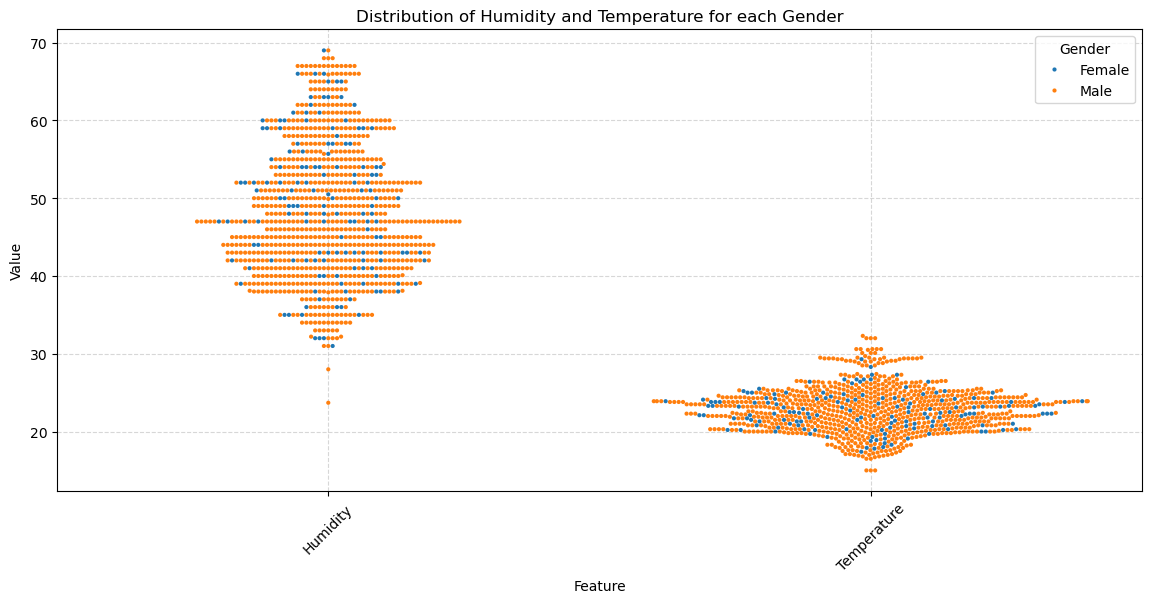

In [21]:
#61. Create a swarm plot to visualize the relationship between humidity and temperature for each gender.

#Map sex values to male and female
df_subject_info['Sex'] = df_subject_info['Sex'].map ({0:'Male', 1:'Female'})
#Drop rows with missing humidity or temperature values
df_subject_info = df_subject_info.dropna (subset= ['Humidity', 'Temperature'])
#Melt the data frame
melted_df = df_subject_info.melt (id_vars= ['Sex'], value_vars= ['Humidity', 'Temperature'], var_name= 'Feature', value_name= 'Value')
#Create swarm plot
plt.figure (figsize= (14,6))
sbn.swarmplot (data= melted_df, x= 'Feature', y= 'Value', hue= 'Sex', size= 3)
plt.title ('Distribution of Humidity and Temperature for each Gender')
plt.xlabel= 'Feature'
plt.ylabel= 'Value'
plt.legend (title= 'Gender')
plt.xticks (rotation= 45)
plt.grid (True, linestyle= '--', alpha= 0.5)
plt.show()

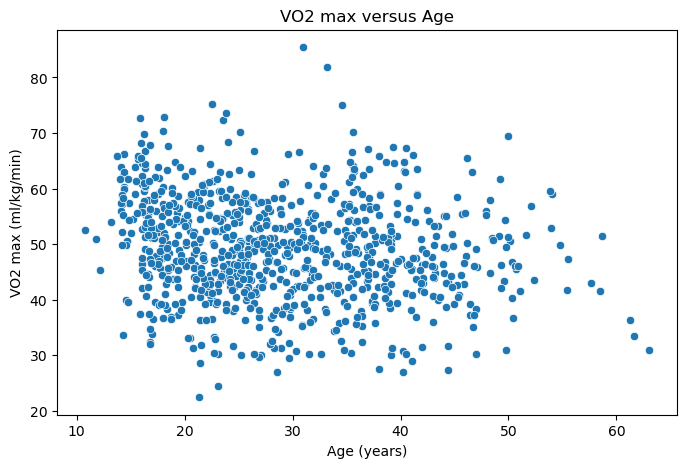

In [9]:
#62. Analyze the relationship between fitness levels and physiological attributes and identify trends in the scatter plot of VO2 max (ml/kg/min) versus age

merged_data = pd.merge (df_subject_info, df_test_measure, on= 'ID')
#Drop rows with missing values in the VO2 column
merged_data = merged_data.dropna (subset= ['VO2'])
#Calculate the index of the maximum VO2 value for each participant. Select the rows from the merged dataframe where the index matches the index of the max VO2 value
df_VO2_max = merged_data.loc [merged_data.groupby ('ID')['VO2'].idxmax()]
#Calculate the VO2 max
df_VO2_max['VO2max'] = df_VO2_max['VO2'] / df_VO2_max['Weight']
#Creates a scatter plot
plt.figure (figsize= (8,5))
sbn.scatterplot (data= df_VO2_max, x= 'Age', y= 'VO2max')
plt.title ('VO2 max versus Age')
plt.xlabel ('Age (years)')
plt.ylabel ('VO2 max (ml/kg/min)')
plt.show()
#Calculating VO@max for each participant and then plotting it against their age

In [24]:
#63 Calculate the warm-up time, GET time, cool-down time, for each athlete test and find athlete who has maximum GET time ?

df_subject_info['Max_HR'] = 220 - df_subject_info['Age']
merged_data = pd.merge(df_test_measure, df_subject_info, on='ID_test')
id_tests = []
warm_up_times = []
cool_down_times = []
get_times = []
times_df = pd.DataFrame (columns= ['ID_test', 'Warm_up_time', 'Get_time', 'Cool_down_time'])
for test_ID in merged_data['ID_test'].unique():
    test_data = merged_data[merged_data['ID_test'] == test_ID]
    if test_data.empty:
        continue
    warm_up_hr = test_data['Max_HR'].iloc[0] * 0.6
    warm_up_data = test_data[test_data['HR'] >= warm_up_hr]
    if not warm_up_data.empty:
        warm_up_time = warm_up_data['time'].min()
    else:
        warm_up_time = None
    get_hr = test_data['Max_HR'].iloc[0] * 0.8
    get_data = test_data[test_data['HR'] >= get_hr]
    if not get_data.empty:
        get_time = get_data['time'].min()
    else:
        get_time = None
    if get_time is not None:
        cool_down_time = test_data['time'].max() - get_time
    else:
        cool_down_time = None
    id_tests.append (test_ID)
    warm_up_times.append (warm_up_time)
    get_times.append (get_time)
    cool_down_times.append (cool_down_time)
times_df = pd.DataFrame ({'ID_test': id_tests, 'Warm_up_time': warm_up_times, 'Get_time': get_times, 'Cool_down_time': cool_down_times})
print ("Warm-up time, GET time, Cool-down time for each athlete test:")
print (times_df)
times_df = times_df.dropna (subset= ['Get_time'])
if not times_df.empty:
    max_get_time = times_df.loc[times_df['Get_time'].idxmax()]
    max_get_time_athlete_id = df_subject_info.loc[df_subject_info['ID_test'] == max_get_time['ID_test'], 'ID'].iloc[0]
    print (f"Athlete with maximum GET time: {max_get_time_athlete_id}")
    print (f"Maximum GET time: {max_get_time['Get_time']}")
else:
    print("No GET time data available")


Warm-up time, GET time, Cool-down time for each athlete test:
    ID_test  Warm_up_time  Get_time  Cool_down_time
0       2_1           250     516.0           530.0
1       3_1           119     366.0           607.0
2       4_1           254     445.0           585.0
3       5_1           219     419.0           518.0
4       6_1           263     532.0           582.0
..      ...           ...       ...             ...
987   855_1           404     670.0           557.0
988   856_3           335     614.0           739.0
989   856_2           342     603.0           656.0
990   856_1           328     571.0           519.0
991   857_1            19     397.0           536.0

[992 rows x 4 columns]
Athlete with maximum GET time: 351
Maximum GET time: 1156.0


In [98]:
#64 Compare the time it takes to multiply each element in a large array by 2 using an explicit loop and a vectorized operation with NumPy 

#Create a large Numpy array
arr = np.arange (1000000)
#Measure the time taken for the explicit loop approach
exp_loop_time = timeit.timeit (lambda: np.array ([x*2 for x in arr]) , number = 1)
print (f"Explicit loop time : {exp_loop_time : .4f} seconds")
#Measure the time taken for the vectorized operation approach
vectorized_time = timeit.timeit (lambda: arr * 2 , number = 1)
print (f"Vectorized Operation time : {vectorized_time : .4f} seconds")
#Compare the explicit loop time and vectorized time
print (f"Vectorized Operation is {exp_loop_time / vectorized_time:.2f}x times faster") 
#number=10 means that the code snippet should be executed 1 time
#Vectorized operations are much faster than loops

Explicit loop time :  0.2211 seconds
Vectorized Operation time :  0.0016 seconds
Vectorized Operation is 142.55x times faster
